# M5 Probabilistic Forecasting — EDA

**Objetivo:** Exploración completa del dataset M5 para entender características, patrones y desafíos.

**Ejecución:** Cloud Workstation, conectado a BigQuery via ADC

**Dataset (fuente: `sales_train_validation.csv`):**
- `sales_long`: 58,327,370 filas, ventas diarias por item+tienda (2011-01-29 → 2016-04-24, 1,913 días)
- `calendar`: Información de fechas, eventos, SNAP (asistencia social)
- `sell_prices`: Precios por item+tienda+semana

> ⚠️ **Nota sobre el dataset:** este EDA (y las Fases 2–6) trabajan exclusivamente sobre `sales_train_validation.csv` (1,913 días → 2011-01-29 a 2016-04-24). Este archivo **no incluye** los últimos 28 días reales de venta. `sales_train_evaluation.csv` (1,941 días, hasta 2016-06-19) ya está subido en GCS pero **se carga a BigQuery recién en la Fase 6**, únicamente para extraer las 28 etiquetas del TEST set (`d_1914`–`d_1941`) como ground truth de la evaluación final. Mantenerlo fuera de BigQuery hasta entonces garantiza que el TEST set esté físicamente bloqueado, no solo bloqueado por convención de código.

**Proyecto:** mle-m5-forecast | **Dataset:** m5_dataset


## Setup: Importes y autenticación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, timedelta
from google.cloud import bigquery
import warnings

warnings.filterwarnings('ignore')

# Configuración
PROJECT = 'mle-m5-forecast'
DATASET = 'm5_dataset'
client = bigquery.Client(project=PROJECT)

# Estilo
#sns.set_theme(style='whitegrid')
#plt.rcParams['figure.figsize'] = (14, 6)
#plt.rcParams['font.size'] = 10

print(f'✓ Conectado a BigQuery: {PROJECT}.{DATASET}')
print(f'✓ Fecha actual: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✓ Conectado a BigQuery: mle-m5-forecast.m5_dataset
✓ Fecha actual: 2026-07-13 02:26:55


## 1. Estructura de datos y tamaños

In [2]:
# Verificar tablas y su tamaño
tables = ['sales_long', 'calendar', 'sell_prices']
table_info = {}

for table_name in tables:
    table_ref = f"{PROJECT}.{DATASET}.{table_name}"
    table = client.get_table(table_ref)
    table_info[table_name] = {
        'rows': table.num_rows,
        'columns': len(table.schema),
        'size_bytes': table.num_bytes,
        'schema': {f.name: f.field_type for f in table.schema}
    }

# Mostrar información
print("\n" + "="*70)
print("ESTRUCTURA DE DATOS")
print("="*70)

for table_name, info in table_info.items():
    size_mb = info['size_bytes'] / 1e6 if info['size_bytes'] else 0
    print(f"\n📊 {table_name.upper()}")
    print(f"   Filas     : {info['rows']:,}")
    print(f"   Columnas  : {info['columns']}")
    print(f"   Tamaño    : {size_mb:.1f} MB")
    print(f"   Schema:")
    for col, dtype in list(info['schema'].items())[:5]:
        print(f"      - {col}: {dtype}")
    if info['columns'] > 5:
        print(f"      ... ({info['columns'] - 5} más)")


ESTRUCTURA DE DATOS

📊 SALES_LONG
   Filas     : 58,327,370
   Columnas  : 5
   Tamaño    : 3936.4 MB
   Schema:
      - id: STRING
      - item_id: STRING
      - store_id: STRING
      - date: DATE
      - sales: INTEGER

📊 CALENDAR
   Filas     : 1,969
   Columnas  : 14
   Tamaño    : 0.2 MB
   Schema:
      - date: DATE
      - wm_yr_wk: INTEGER
      - weekday: STRING
      - wday: INTEGER
      - month: INTEGER
      ... (9 más)

📊 SELL_PRICES
   Filas     : 6,841,121
   Columnas  : 4
   Tamaño    : 251.5 MB
   Schema:
      - store_id: STRING
      - item_id: STRING
      - wm_yr_wk: INTEGER
      - sell_price: FLOAT


## 2. Rango temporal y estadísticas básicas

In [3]:
# Estadísticas temporales
query = f"""
SELECT 
  MIN(date) as fecha_inicio,
  MAX(date) as fecha_fin,
  COUNT(DISTINCT date) as dias_totales,
  DATE_DIFF(MAX(date), MIN(date), DAY) + 1 as dias_calendario,
  COUNT(DISTINCT CONCAT(item_id, '_', store_id)) as series_unicas,
  COUNT(*) as total_registros,
  ROUND(COUNT(*) / COUNT(DISTINCT CONCAT(item_id, '_', store_id)), 0) as filas_promedio_por_serie
FROM `{PROJECT}.{DATASET}.sales_long`
"""

result = client.query(query).to_dataframe()

print("\n" + "="*70)
print("ESTADÍSTICAS TEMPORALES")
print("="*70)

for idx, row in result.iterrows():
    print(f"\n⏰ Período:")
    print(f"   Inicio            : {row['fecha_inicio']}")
    print(f"   Fin               : {row['fecha_fin']}")
    print(f"   Días únicos       : {row['dias_totales']:,}")
    print(f"   Días calendario   : {row['dias_calendario']:,}")
    print(f"\n📈 Series:")
    print(f"   Series únicas     : {row['series_unicas']:,}")
    print(f"   Total registros   : {row['total_registros']:,}")
    print(f"   Filas/serie medio : {row['filas_promedio_por_serie']:,.0f}")


ESTADÍSTICAS TEMPORALES

⏰ Período:
   Inicio            : 2011-01-29
   Fin               : 2016-04-24
   Días únicos       : 1,913
   Días calendario   : 1,913

📈 Series:
   Series únicas     : 30,490
   Total registros   : 58,327,370
   Filas/serie medio : 1,913


## 3. Distribución de ventas por categoría

In [4]:
# Extraer categoría del item_id (ej: FOODS_001 → FOODS)
query = f"""
SELECT 
  REGEXP_SUBSTR(item_id, r'^[A-Z]+') as categoria,
  COUNT(*) as registros,
  COUNT(DISTINCT CONCAT(item_id, '_', store_id)) as series,
  COUNT(DISTINCT store_id) as tiendas,
  COUNT(DISTINCT item_id) as items,
  ROUND(AVG(sales), 2) as venta_promedio,
  ROUND(STDDEV(sales), 2) as venta_desv,
  MIN(sales) as venta_min,
  MAX(sales) as venta_max,
  COUNTIF(sales = 0) as registros_cero,
  ROUND(100 * COUNTIF(sales = 0) / COUNT(*), 2) as pct_ceros
FROM `{PROJECT}.{DATASET}.sales_long`
GROUP BY categoria
ORDER BY registros DESC
"""

df_cat = client.query(query).to_dataframe()


DISTRIBUCIÓN POR CATEGORÍA

categoria  registros  series  tiendas  items  venta_promedio  venta_desv  venta_min  venta_max  registros_cero  pct_ceros
    FOODS   27489810   14370       10   1437            1.64        5.15          0        763        17049511      62.02
HOUSEHOLD   20029110   10470       10   1047            0.72        2.09          0        626        14374806      71.77
  HOBBIES   10808450    5650       10    565            0.57        2.04          0        294         8352777      77.28


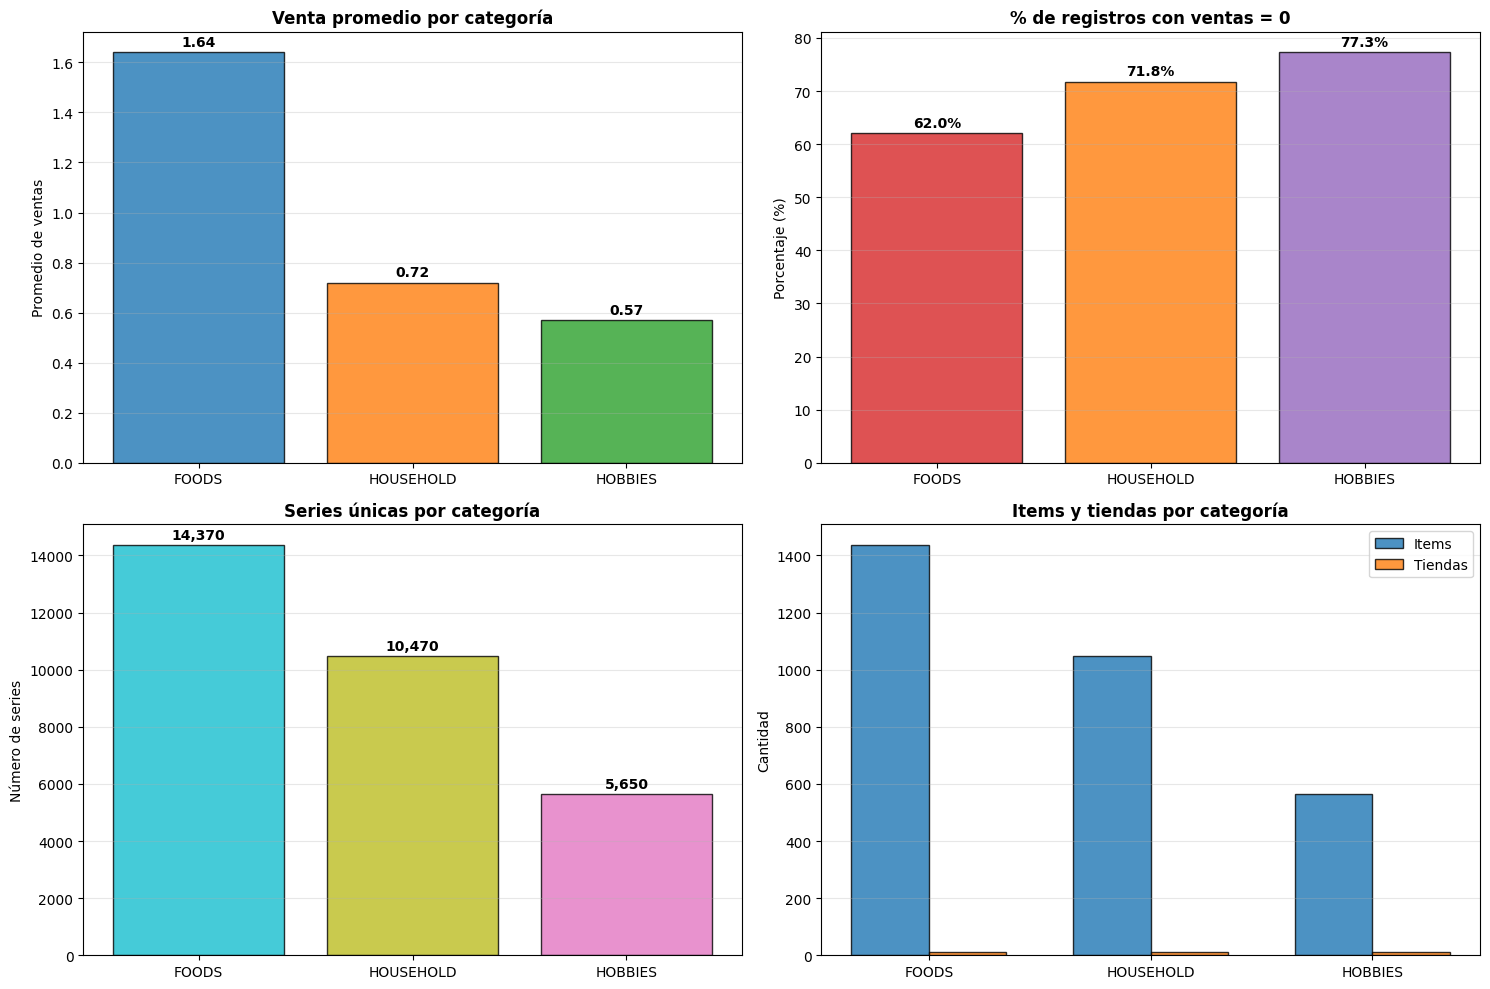

In [5]:
print("\n" + "="*70)
print("DISTRIBUCIÓN POR CATEGORÍA")
print("="*70)
print(f"\n{df_cat.to_string(index=False)}")

# Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Venta promedio
axes[0, 0].bar(df_cat['categoria'], df_cat['venta_promedio'], 
               color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8, edgecolor='black')
axes[0, 0].set_title('Venta promedio por categoría', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Promedio de ventas')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_cat['venta_promedio']):
    axes[0, 0].text(i, v + df_cat['venta_promedio'].max() * 0.015, f'{v:.2f}', ha='center', fontweight='bold')

# Tasa de ceros
axes[0, 1].bar(df_cat['categoria'], df_cat['pct_ceros'], 
               color=['#d62728', '#ff7f0e', '#9467bd'], alpha=0.8, edgecolor='black')
axes[0, 1].set_title('% de registros con ventas = 0', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Porcentaje (%)')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_cat['pct_ceros']):
    axes[0, 1].text(i, v + df_cat['pct_ceros'].max() * 0.015, f'{v:.1f}%', ha='center', fontweight='bold')

# Series por categoría
axes[1, 0].bar(df_cat['categoria'], df_cat['series'], 
               color=['#17becf', '#bcbd22', '#e377c2'], alpha=0.8, edgecolor='black')
axes[1, 0].set_title('Series únicas por categoría', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Número de series')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_cat['series']):
    axes[1, 0].text(i, v + df_cat['series'].max() * 0.015, f'{v:,}', ha='center', fontweight='bold')

# Items y tiendas
x = np.arange(len(df_cat))
width = 0.35
axes[1, 1].bar(x - width/2, df_cat['items'], width, label='Items', alpha=0.8, edgecolor='black')
axes[1, 1].bar(x + width/2, df_cat['tiendas'], width, label='Tiendas', alpha=0.8, edgecolor='black')
axes[1, 1].set_title('Items y tiendas por categoría', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(df_cat['categoria'])
axes[1, 1].set_ylabel('Cantidad')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Tasa de ceros: serie por serie


TASA DE CEROS POR SERIE (Crítico para modelado)

              categoria_ceros  series  pct_series  venta_prom_categoria
  2. Muy lento (75-99% ceros)   14534       47.67                  0.21
      3. Lento (50-75% ceros)    9382       30.77                  0.84
   4. Moderado (25-50% ceros)    5014       16.44                  2.53
5. Pocas faltas (1-25% ceros)    1560        5.12                  6.90


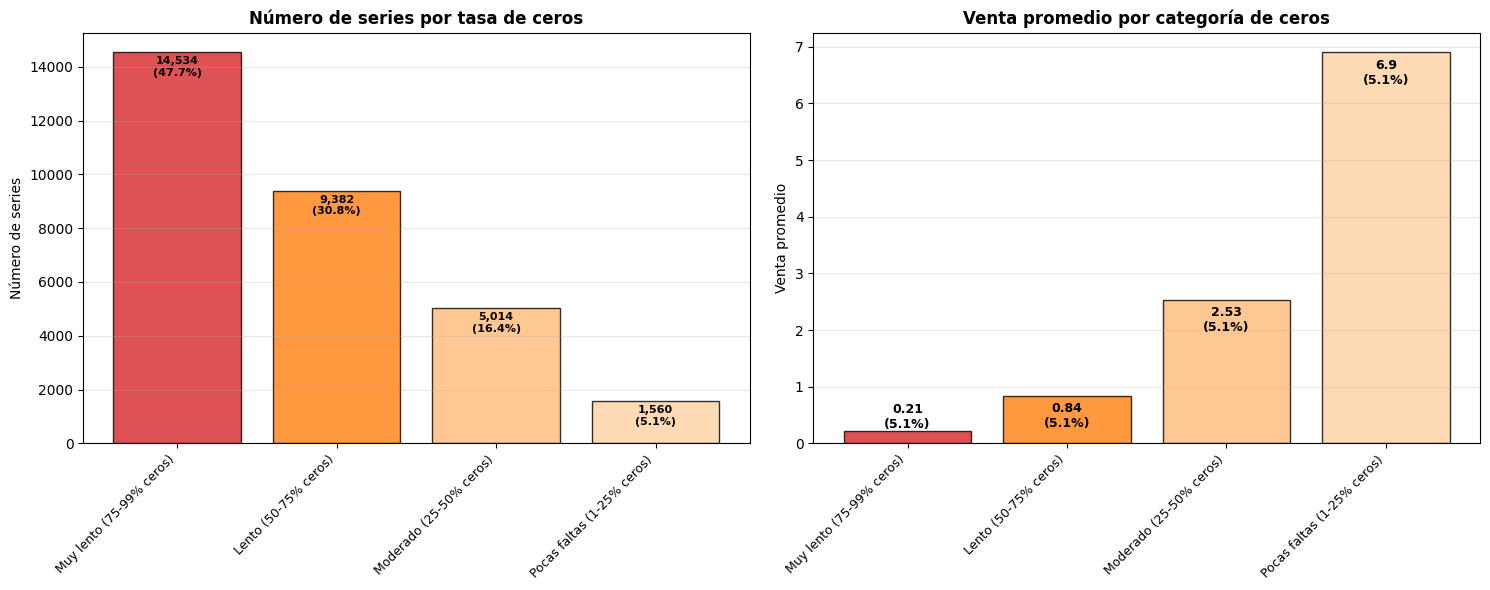

In [6]:
# Distribución de series por tasa de ceros (CRÍTICA para modelado)
query = f"""
WITH serie_stats AS (
  SELECT 
    CONCAT(item_id, '_', store_id) as serie,
    COUNT(*) as total_dias,
    COUNTIF(sales = 0) as dias_cero,
    ROUND(100 * COUNTIF(sales = 0) / COUNT(*), 2) as pct_ceros,
    ROUND(AVG(sales), 2) as venta_promedio
  FROM `{PROJECT}.{DATASET}.sales_long`
  GROUP BY serie
)
SELECT 
  CASE 
    WHEN pct_ceros = 100 THEN '1. Sin ventas (100% ceros)'
    WHEN pct_ceros >= 75 THEN '2. Muy lento (75-99% ceros)'
    WHEN pct_ceros >= 50 THEN '3. Lento (50-75% ceros)'
    WHEN pct_ceros >= 25 THEN '4. Moderado (25-50% ceros)'
    WHEN pct_ceros > 0 THEN '5. Pocas faltas (1-25% ceros)'
    ELSE '6. Completo (0% ceros)'
  END as categoria_ceros,
  COUNT(*) as series,
  ROUND(100 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) as pct_series,
  ROUND(AVG(venta_promedio), 2) as venta_prom_categoria
FROM serie_stats
GROUP BY categoria_ceros
ORDER BY categoria_ceros
"""

df_ceros = client.query(query).to_dataframe()

print("\n" + "="*70)
print("TASA DE CEROS POR SERIE (Crítico para modelado)")
print("="*70)
print(f"\n{df_ceros.to_string(index=False)}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Distribución de series
colors_ceros = ['#d62728', '#ff7f0e', '#ffbb78', '#fdd0a2', '#bcbd22', '#17becf']
axes[0].bar(range(len(df_ceros)), df_ceros['series'], color=colors_ceros, edgecolor='black', alpha=0.8)
axes[0].set_xticks(range(len(df_ceros)))
axes[0].set_xticklabels([c.split('. ')[1] for c in df_ceros['categoria_ceros']], 
                         rotation=45, ha='right', fontsize=9)
axes[0].set_title('Número de series por tasa de ceros', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de series')
axes[0].grid(axis='y', alpha=0.3)
for i, (v, p) in enumerate(zip(df_ceros['series'], df_ceros['pct_series'])):
    axes[0].text(i, v - df_ceros['series'].max() * 0.06, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=8, fontweight='bold')


# Venta promedio por categoría de ceros
axes[1].bar(range(len(df_ceros)), df_ceros['venta_prom_categoria'], 
            color=colors_ceros, edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(len(df_ceros)))
axes[1].set_xticklabels([c.split('. ')[1] for c in df_ceros['categoria_ceros']], 
                         rotation=45, ha='right', fontsize=9)
axes[1].set_title('Venta promedio por categoría de ceros', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Venta promedio')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_ceros['venta_prom_categoria']):
    hpos = v - df_ceros['venta_prom_categoria'].max() * 0.08
    if hpos <= df_ceros['venta_prom_categoria'].max() * 0.035:
        hpos = v + df_ceros['venta_prom_categoria'].max() * 0.008
    axes[1].text(i, hpos, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Variación de precios


ANÁLISIS DE PRECIOS

categoria  registros_precio  precio_promedio  precio_desv  precio_min  precio_max  coef_variacion
HOUSEHOLD           2375427             5.47         3.38        0.01      107.32           61.76
  HOBBIES           1283905             5.33         4.83        0.01       30.98           90.53
    FOODS           3181789             3.25         2.13        0.01       19.48           65.59


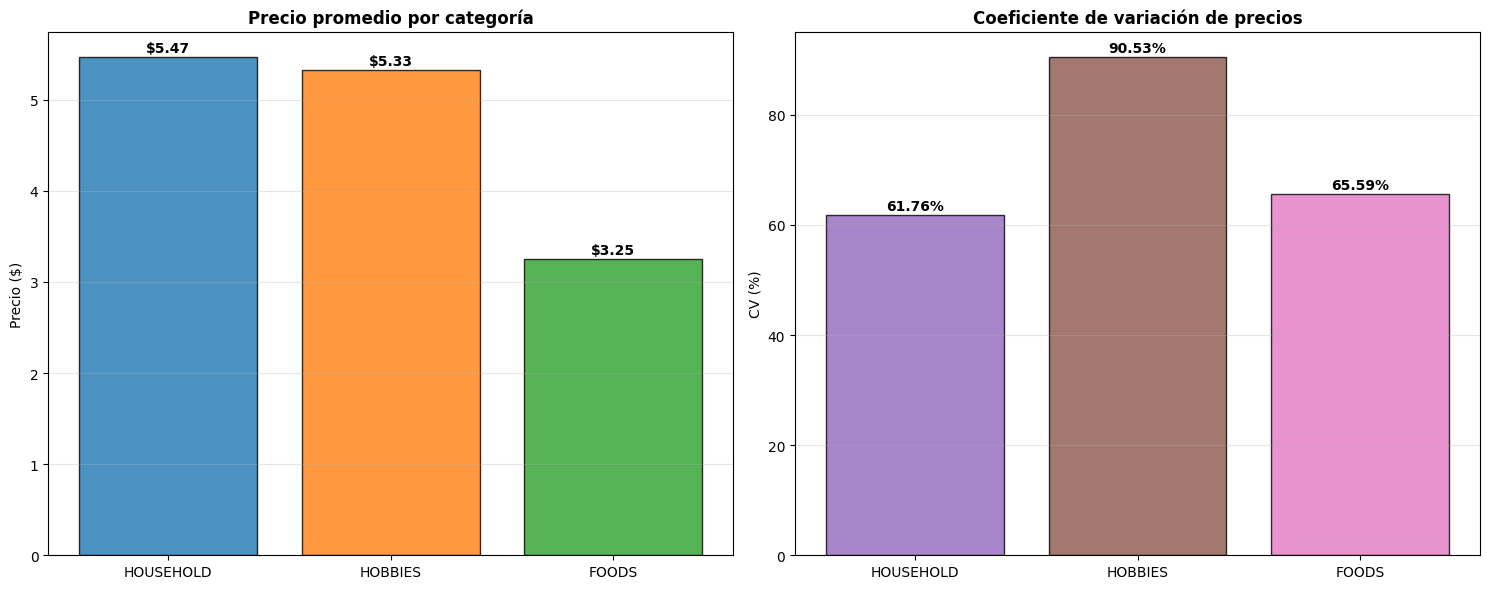

In [7]:
# Estadísticas de precios
query = f"""
SELECT 
  REGEXP_SUBSTR(item_id, r'^[A-Z]+') as categoria,
  COUNT(*) as registros_precio,
  ROUND(AVG(sell_price), 2) as precio_promedio,
  ROUND(STDDEV(sell_price), 2) as precio_desv,
  MIN(sell_price) as precio_min,
  MAX(sell_price) as precio_max,
  ROUND(100 * STDDEV(sell_price) / AVG(sell_price), 2) as coef_variacion
FROM `{PROJECT}.{DATASET}.sell_prices`
GROUP BY categoria
ORDER BY precio_promedio DESC
"""

df_precios = client.query(query).to_dataframe()

print("\n" + "="*70)
print("ANÁLISIS DE PRECIOS")
print("="*70)
print(f"\n{df_precios.to_string(index=False)}")

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Precio promedio
axes[0].bar(df_precios['categoria'], df_precios['precio_promedio'], 
            color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8, edgecolor='black')
axes[0].set_title('Precio promedio por categoría', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Precio ($)')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_precios['precio_promedio']):
    axes[0].text(i, v + df_precios['precio_promedio'].max() * 0.01, f'${v:.2f}', ha='center', fontweight='bold')

# Coeficiente de variación
axes[1].bar(df_precios['categoria'], df_precios['coef_variacion'], 
            color=['#9467bd', '#8c564b', '#e377c2'], alpha=0.8, edgecolor='black')
axes[1].set_title('Coeficiente de variación de precios', fontsize=12, fontweight='bold')
axes[1].set_ylabel('CV (%)')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_precios['coef_variacion']):
    axes[1].text(i, v + df_precios['coef_variacion'].max() * 0.01, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Eventos y SNAP


EVENTOS Y ASISTENCIA SOCIAL (SNAP)

🎉 Tipos de eventos:
tipo_evento  ocurrencias  dias_unicos
  Religious           55           55
   National           52           52
   Cultural           37           37
   Sporting           18           18

🏪 Días con SNAP activo por estado:
   California: 650 días (33.0%)
   Texas     : 650 días (33.0%)
   Wisconsin : 650 días (33.0%)


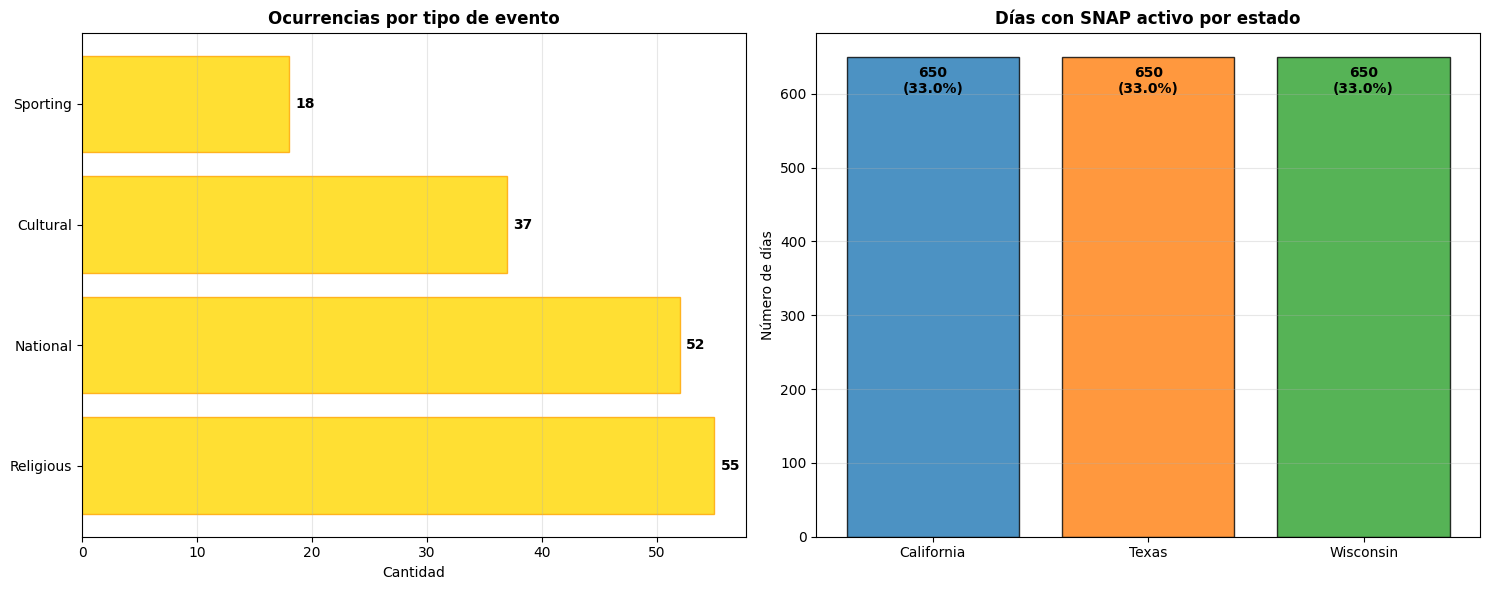

In [8]:
# Distribución de eventos
query = f"""
SELECT 
  event_type_1 as tipo_evento,
  COUNT(*) as ocurrencias,
  COUNT(DISTINCT date) as dias_unicos
FROM `{PROJECT}.{DATASET}.calendar`
WHERE event_type_1 IS NOT NULL
GROUP BY event_type_1
ORDER BY ocurrencias DESC
"""

df_eventos = client.query(query).to_dataframe()

# SNAP por estado
query_snap = f"""
SELECT 
  SUM(snap_CA) as snap_ca_dias,
  SUM(snap_TX) as snap_tx_dias,
  SUM(snap_WI) as snap_wi_dias,
  COUNT(*) as total_dias
FROM `{PROJECT}.{DATASET}.calendar`
"""

df_snap = client.query(query_snap).to_dataframe()

print("\n" + "="*70)
print("EVENTOS Y ASISTENCIA SOCIAL (SNAP)")
print("="*70)

print(f"\n🎉 Tipos de eventos:")
print(f"{df_eventos.to_string(index=False)}")

print(f"\n🏪 Días con SNAP activo por estado:")
for idx, row in df_snap.iterrows():
    print(f"   California: {row['snap_ca_dias']} días ({100*row['snap_ca_dias']/row['total_dias']:.1f}%)")
    print(f"   Texas     : {row['snap_tx_dias']} días ({100*row['snap_tx_dias']/row['total_dias']:.1f}%)")
    print(f"   Wisconsin : {row['snap_wi_dias']} días ({100*row['snap_wi_dias']/row['total_dias']:.1f}%)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Eventos
axes[0].barh(df_eventos['tipo_evento'], df_eventos['ocurrencias'], 
             color='gold', edgecolor='orange', alpha=0.8)
axes[0].set_title('Ocurrencias por tipo de evento', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cantidad')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(df_eventos['ocurrencias']):
    axes[0].text(v + df_eventos['ocurrencias'].max() * 0.01, i, str(int(v)), va='center', fontweight='bold')

# SNAP
snap_data = [
    df_snap.iloc[0]['snap_ca_dias'],
    df_snap.iloc[0]['snap_tx_dias'],
    df_snap.iloc[0]['snap_wi_dias']
]
snap_labels = ['California', 'Texas', 'Wisconsin']
axes[1].bar(snap_labels, snap_data, color=['#1f77b4', '#ff7f0e', '#2ca02c'], 
            alpha=0.8, edgecolor='black')
axes[1].set_title('Días con SNAP activo por estado', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Número de días')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(snap_data):
    pct = 100 * v / df_snap.iloc[0]['total_dias']
    axes[1].text(i, v - df_snap['total_dias'].max() * 0.025, f'{int(v)}\n({pct:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Series de tiempo: ejemplos representativos


SERIES REPRESENTATIVAS

                tipo     item_id store_id
        Alto volumen FOODS_3_586     TX_2
    Volumen moderado FOODS_3_090     CA_3
Bajo volumen (lento) FOODS_3_070     WI_2


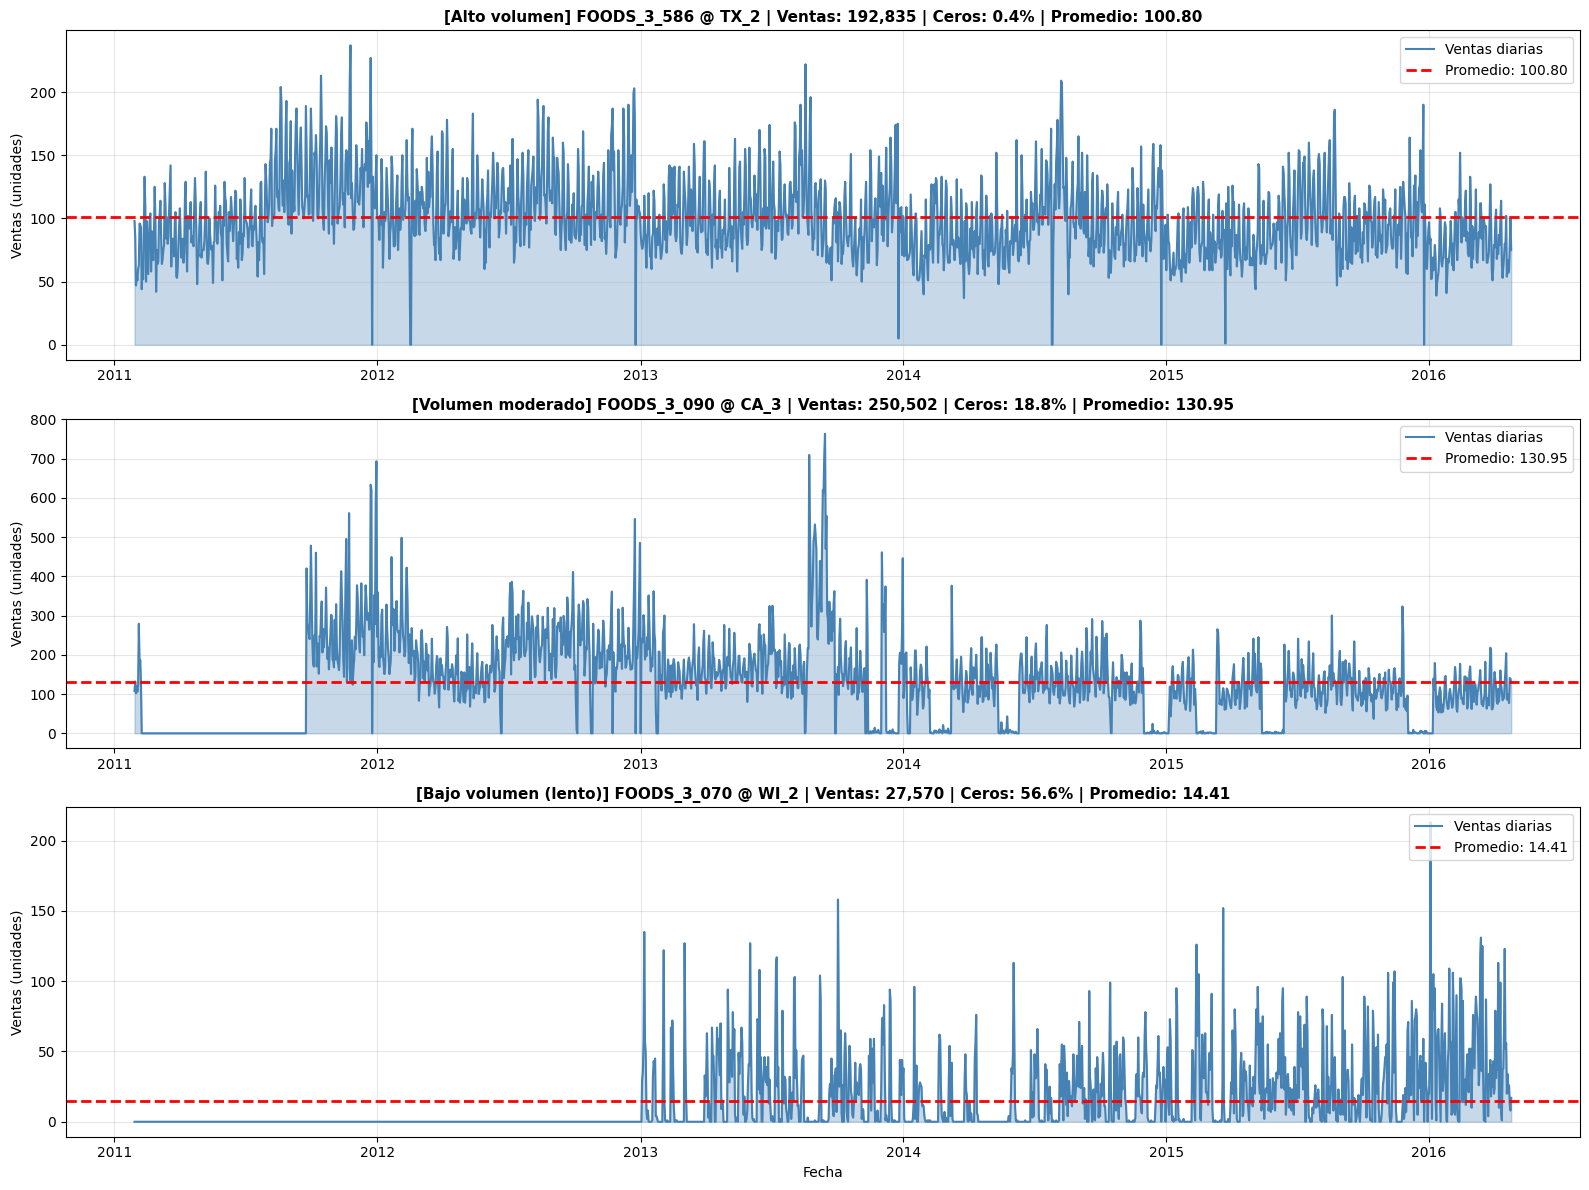

In [9]:
# Encontrar series representativas
query = f"""
WITH serie_stats AS (
  SELECT 
    item_id,
    store_id,
    CONCAT(item_id, '_', store_id) as serie,
    SUM(sales) as total_ventas,
    COUNTIF(sales = 0) as dias_cero,
    COUNT(*) as total_dias,
    ROUND(100 * COUNTIF(sales = 0) / COUNT(*), 2) as pct_ceros,
    AVG(sales) as venta_media
  FROM `{PROJECT}.{DATASET}.sales_long`
  GROUP BY item_id, store_id
)
(
  SELECT 
    'Alto volumen' as tipo,
    item_id,
    store_id
  FROM serie_stats
  WHERE pct_ceros < 5
  ORDER BY total_ventas DESC
  LIMIT 1
)
UNION ALL
(
  SELECT 
    'Bajo volumen (lento)' as tipo,
    item_id,
    store_id
  FROM serie_stats
  WHERE pct_ceros > 50 AND pct_ceros < 100
  ORDER BY total_ventas DESC
  LIMIT 1
)
UNION ALL
(
  SELECT 
    'Volumen moderado' as tipo,
    item_id,
    store_id
  FROM serie_stats
  WHERE pct_ceros >= 0 AND pct_ceros <= 30
  ORDER BY total_ventas DESC
  LIMIT 1
)
"""

example_series = client.query(query).to_dataframe()

print("\n" + "="*70)
print("SERIES REPRESENTATIVAS")
print("="*70)
print(f"\n{example_series.to_string(index=False)}")

# Graficar cada serie
fig, axes = plt.subplots(len(example_series), 1, figsize=(16, 4 * len(example_series)))
if len(example_series) == 1:
    axes = [axes]

for idx, (_, row) in enumerate(example_series.iterrows()):
    item_id = row['item_id']
    store_id = row['store_id']
    tipo = row['tipo']

    query_ts = f"""
    SELECT 
      date,
      sales
    FROM `{PROJECT}.{DATASET}.sales_long`
    WHERE item_id = '{item_id}' AND store_id = '{store_id}'
    ORDER BY date
    """
    
    df_ts = client.query(query_ts).to_dataframe()
    
    # Calcular estadísticas
    total_ventas = df_ts['sales'].sum()
    pct_ceros = 100 * (df_ts['sales'] == 0).sum() / len(df_ts)
    venta_promedio = df_ts['sales'].mean()
    
    axes[idx].plot(df_ts['date'], df_ts['sales'], linewidth=1.5, color='steelblue', label='Ventas diarias')
    axes[idx].fill_between(df_ts['date'], df_ts['sales'], alpha=0.3, color='steelblue')
    axes[idx].axhline(y=venta_promedio, color='red', linestyle='--', linewidth=2, label=f'Promedio: {venta_promedio:.2f}')
    
    title = f"[{tipo}] {item_id} @ {store_id} | Ventas: {total_ventas:,.0f} | Ceros: {pct_ceros:.1f}% | Promedio: {venta_promedio:.2f}"
    axes[idx].set_title(title, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Ventas (unidades)')
    axes[idx].grid(alpha=0.3)
    axes[idx].legend(loc='upper right')

axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

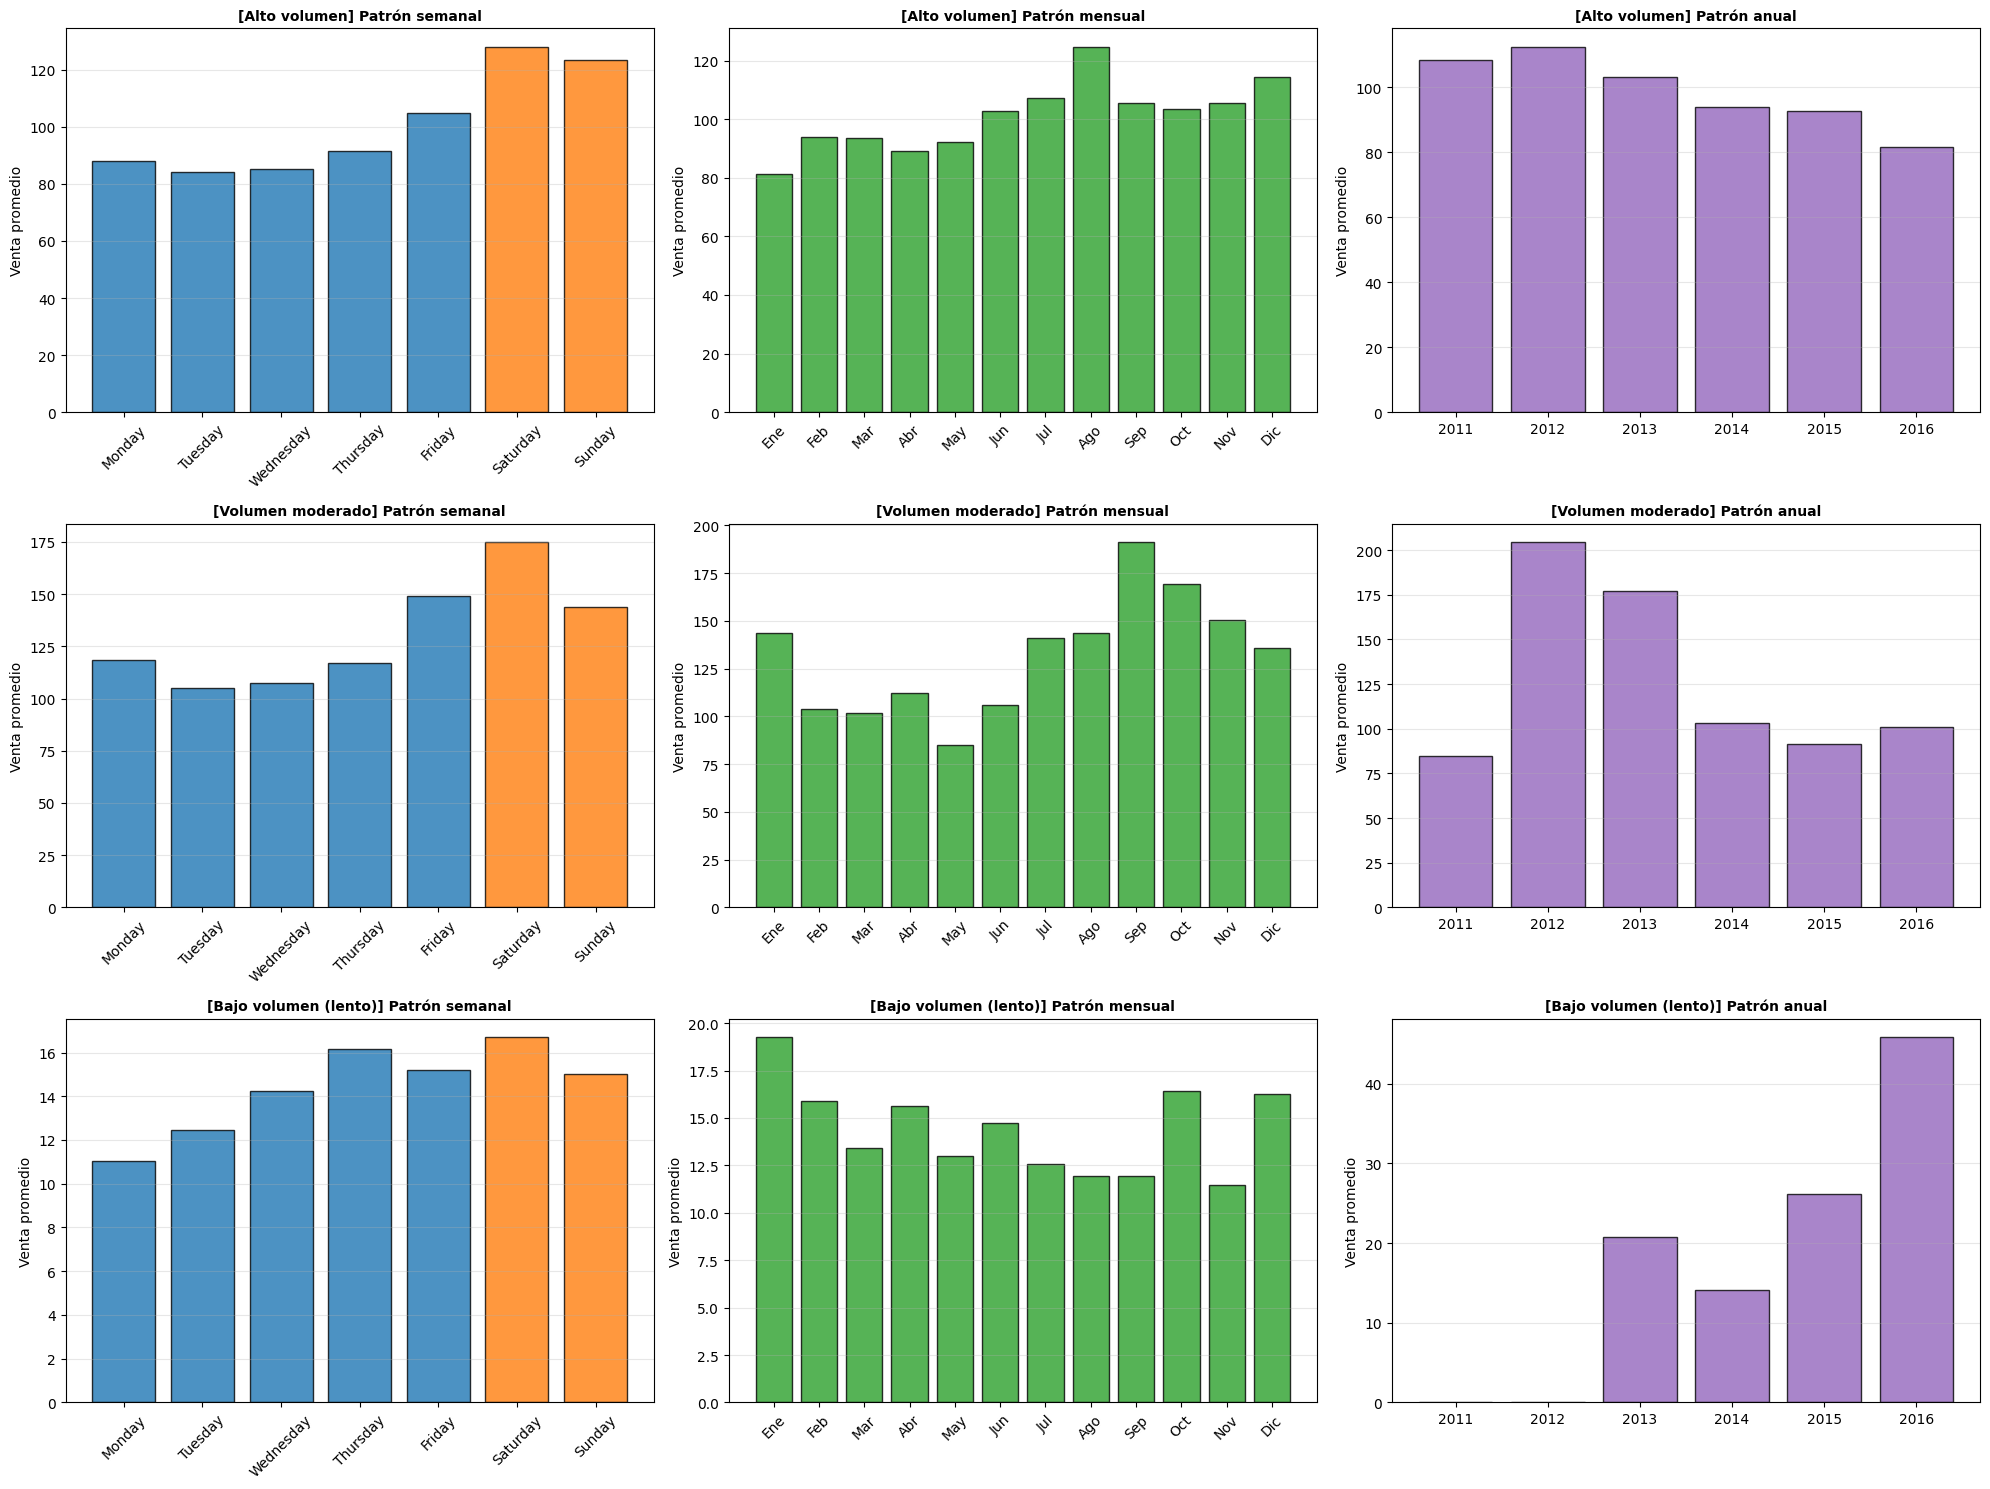

In [10]:
# Patrones estacionales de las series representativas: semanal, mensual y anual
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, axes = plt.subplots(len(example_series), 3, figsize=(20, 5 * len(example_series)))
if len(example_series) == 1:
    axes = axes.reshape(1, -1)

for idx, (_, row) in enumerate(example_series.iterrows()):
    item_id = row['item_id']
    store_id = row['store_id']
    tipo = row['tipo']

    query_ts = f"""
    SELECT 
      date,
      sales
    FROM `{PROJECT}.{DATASET}.sales_long`
    WHERE item_id = '{item_id}' AND store_id = '{store_id}'
    ORDER BY date
    """
    df_ts = client.query(query_ts).to_dataframe()
    df_ts['date'] = pd.to_datetime(df_ts['date'])
    df_ts['weekday'] = df_ts['date'].dt.day_name()
    df_ts['month'] = df_ts['date'].dt.month
    df_ts['year'] = df_ts['date'].dt.year

    # --- Patrón semanal (día de la semana) ---
    dow_avg = df_ts.groupby('weekday')['sales'].mean().reindex(weekday_order)
    colors_dow = ['#ff7f0e' if d in ['Saturday', 'Sunday'] else '#1f77b4' for d in weekday_order]
    axes[idx, 0].bar(weekday_order, dow_avg.values, color=colors_dow, alpha=0.8, edgecolor='black')
    axes[idx, 0].set_title(f'[{tipo}] Patrón semanal', fontsize=10, fontweight='bold')
    axes[idx, 0].set_ylabel('Venta promedio')
    axes[idx, 0].tick_params(axis='x', rotation=45)
    axes[idx, 0].grid(axis='y', alpha=0.3)

    # --- Patrón mensual ---
    month_avg = df_ts.groupby('month')['sales'].mean().reindex(range(1, 13))
    axes[idx, 1].bar(month_names, month_avg.values, color='#2ca02c', alpha=0.8, edgecolor='black')
    axes[idx, 1].set_title(f'[{tipo}] Patrón mensual', fontsize=10, fontweight='bold')
    axes[idx, 1].set_ylabel('Venta promedio')
    axes[idx, 1].tick_params(axis='x', rotation=45)
    axes[idx, 1].grid(axis='y', alpha=0.3)

    # --- Patrón anual ---
    year_avg = df_ts.groupby('year')['sales'].mean()
    axes[idx, 2].bar(year_avg.index.astype(str), year_avg.values, color='#9467bd', alpha=0.8, edgecolor='black')
    axes[idx, 2].set_title(f'[{tipo}] Patrón anual', fontsize=10, fontweight='bold')
    axes[idx, 2].set_ylabel('Venta promedio')
    axes[idx, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Patrones estacionales


PATRONES ESTACIONALES

📅 Venta promedio por día de la semana:
  weekday  venta_promedio
 Saturday            1.36
   Sunday            1.35
   Monday            1.08
  Tuesday            1.00
Wednesday            0.98
 Thursday            0.99
   Friday            1.12


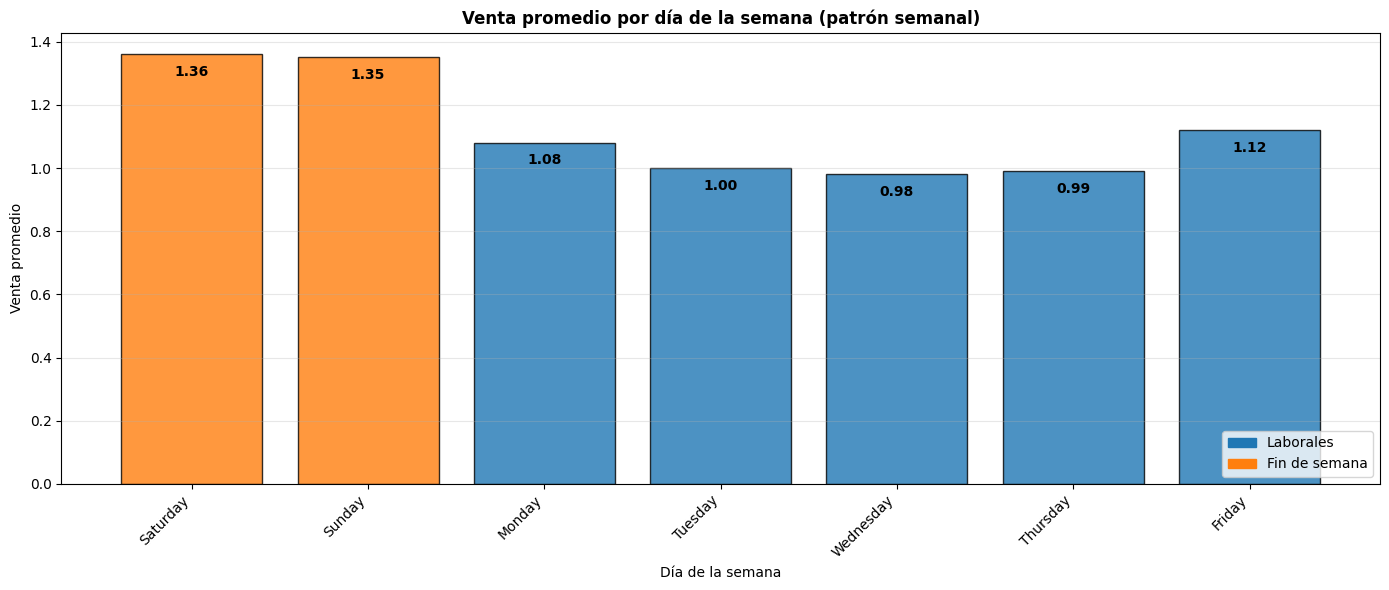

In [11]:
# Patrones de día de la semana
query = f"""
WITH daily_agg AS (
  SELECT 
    c.weekday,
    EXTRACT(DAYOFWEEK FROM sl.date) as dow,
    ROUND(AVG(sl.sales), 2) as venta_promedio,
    COUNT(sl.sales) as registros
  FROM `{PROJECT}.{DATASET}.sales_long` sl
  LEFT JOIN `{PROJECT}.{DATASET}.calendar` c ON sl.date = c.date
  GROUP BY c.weekday, EXTRACT(DAYOFWEEK FROM sl.date)
)
SELECT 
  weekday,
  ROUND(AVG(venta_promedio), 2) as venta_promedio
FROM daily_agg
WHERE weekday IS NOT NULL
GROUP BY weekday
ORDER BY 
  CASE WHEN weekday = 'Saturday' THEN 0
       WHEN weekday = 'Sunday' THEN 1
       WHEN weekday = 'Monday' THEN 2
       WHEN weekday = 'Tuesday' THEN 3
       WHEN weekday = 'Wednesday' THEN 4
       WHEN weekday = 'Thursday' THEN 5
       WHEN weekday = 'Friday' THEN 6
  END
"""

df_dow = client.query(query).to_dataframe()

print("\n" + "="*70)
print("PATRONES ESTACIONALES")
print("="*70)
print(f"\n📅 Venta promedio por día de la semana:")
print(f"{df_dow.to_string(index=False)}")

# Visualización
plt.figure(figsize=(14, 6))
colors = ['#ff7f0e' if day in ['Saturday', 'Sunday'] else '#1f77b4' for day in df_dow['weekday']]
bars = plt.bar(df_dow['weekday'], df_dow['venta_promedio'], color=colors, alpha=0.8, edgecolor='black')
plt.title('Venta promedio por día de la semana (patrón semanal)', fontsize=12, fontweight='bold')
plt.ylabel('Venta promedio')
plt.xlabel('Día de la semana')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(df_dow['venta_promedio']):
    plt.text(i, v - df_dow['venta_promedio'].max() * 0.05, f'{v:.2f}', ha='center', fontweight='bold')

laborales_patch = mpatches.Patch(color='#1f77b4', label='Laborales')
finde_patch = mpatches.Patch(color='#ff7f0e', label='Fin de semana')
plt.legend(handles=[laborales_patch, finde_patch], loc='lower right')

plt.tight_layout()
plt.show()


PATRONES MENSUAL Y ANUAL

📅 Venta promedio por mes:
 mes  venta_promedio
   1            1.11
   2            1.14
   3            1.13
   4            1.12
   5            1.07
   6            1.15
   7            1.15
   8            1.18
   9            1.16
  10            1.14
  11            1.09
  12            1.08

📅 Venta promedio por año:
 anio  venta_promedio  dias_en_anio
 2011            0.86           337
 2012            1.08           366
 2013            1.18           365
 2014            1.18           365
 2015            1.24           365
 2016            1.35           115


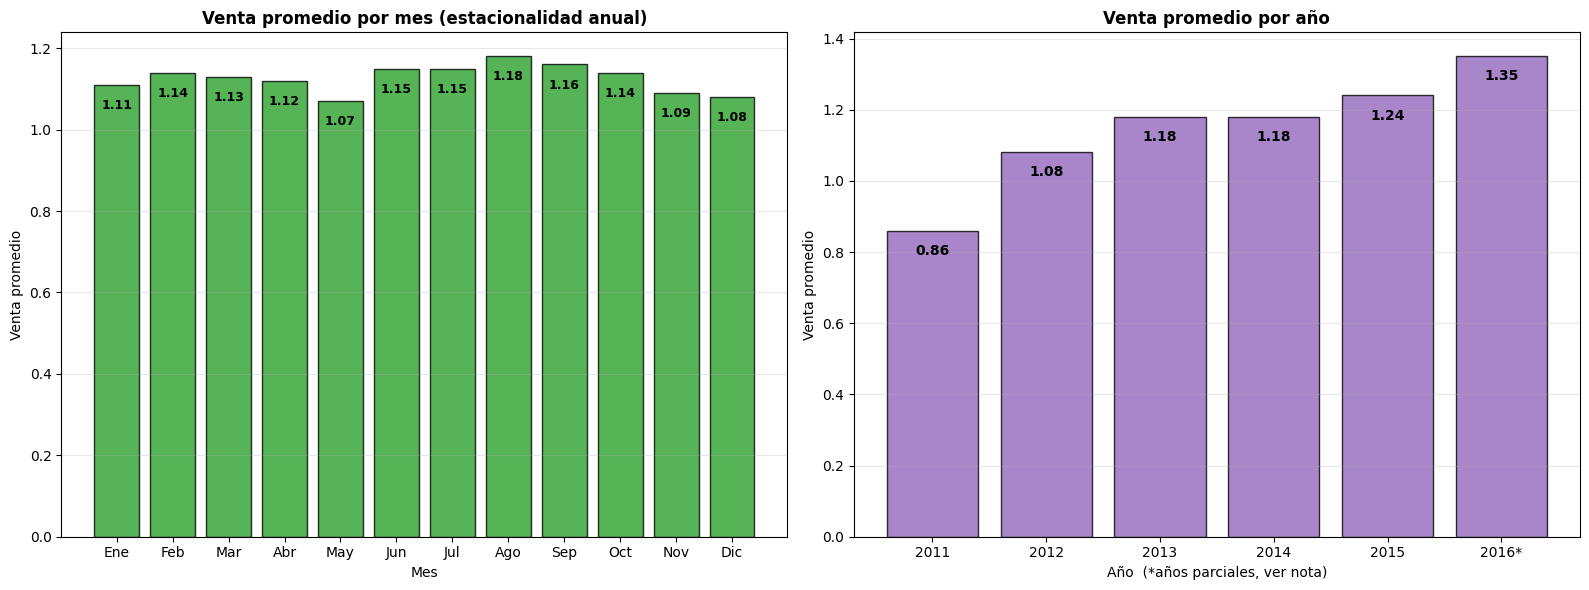


⚠️  Nota: los años marcados con * tienen menos de 300 días de datos
   (2011 arranca el 29-ene, 2016 termina el 24-abr) — no comparar
   directamente su promedio anual contra años completos.


In [12]:
# Patrones mensual y anual (a nivel de todo el dataset)
query_month = f"""
SELECT 
  c.month as mes,
  ROUND(AVG(sl.sales), 2) as venta_promedio
FROM `{PROJECT}.{DATASET}.sales_long` sl
LEFT JOIN `{PROJECT}.{DATASET}.calendar` c ON sl.date = c.date
WHERE c.month IS NOT NULL
GROUP BY mes
ORDER BY mes
"""
df_month = client.query(query_month).to_dataframe()

query_year = f"""
SELECT 
  c.year as anio,
  ROUND(AVG(sl.sales), 2) as venta_promedio,
  COUNT(DISTINCT sl.date) as dias_en_anio
FROM `{PROJECT}.{DATASET}.sales_long` sl
LEFT JOIN `{PROJECT}.{DATASET}.calendar` c ON sl.date = c.date
WHERE c.year IS NOT NULL
GROUP BY anio
ORDER BY anio
"""
df_year = client.query(query_year).to_dataframe()

print("\n" + "="*70)
print("PATRONES MENSUAL Y ANUAL")
print("="*70)
print(f"\n📅 Venta promedio por mes:")
print(f"{df_month.to_string(index=False)}")
print(f"\n📅 Venta promedio por año:")
print(f"{df_year.to_string(index=False)}")

month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Patrón mensual
axes[0].bar(month_names, df_month['venta_promedio'], color='#2ca02c', alpha=0.8, edgecolor='black')
axes[0].set_title('Venta promedio por mes (estacionalidad anual)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Venta promedio')
axes[0].set_xlabel('Mes')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_month['venta_promedio']):
    axes[0].text(i, v - df_month['venta_promedio'].max() * 0.05, f'{v:.2f}', ha='center', fontweight='bold', fontsize=9)

# Patrón anual
year_labels = [f"{int(a)}*" if d < 300 else str(int(a)) 
               for a, d in zip(df_year['anio'], df_year['dias_en_anio'])]
axes[1].bar(year_labels, df_year['venta_promedio'], color='#9467bd', alpha=0.8, edgecolor='black')
axes[1].set_title('Venta promedio por año', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Venta promedio')
axes[1].set_xlabel('Año  (*años parciales, ver nota)')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(df_year['venta_promedio']):
    axes[1].text(i, v - df_year['venta_promedio'].max() * 0.05, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

if (df_year['dias_en_anio'] < 300).any():
    print("\n⚠️  Nota: los años marcados con * tienen menos de 300 días de datos")
    print("   (2011 arranca el 29-ene, 2016 termina el 24-abr) — no comparar")
    print("   directamente su promedio anual contra años completos.")